# Bushfire At Risk Register – Exploratory Data Analysis

## Purpose

This notebook performs exploratory data analysis and data-quality assessment on the FireFusion Bushfire At Risk Register dataset.

The analysis will examine:

- Dataset structure and size
- Missing and empty values
- Duplicate records
- Fire risk categories
- Education sectors
- Town/Suburb values
- Local Government Areas (LGAs)
- Fire weather districts
- Formatting inconsistencies
- Potential data-quality issues

The original source dataset will not be modified during the exploratory analysis.

In [17]:
import json
import pandas as pd
from pathlib import Path

## 1. Load the Dataset

The Bushfire At Risk Register is stored as a JSON file containing Victorian facilities identified within bushfire risk areas.

The dataset is loaded into a pandas DataFrame so that its structure and data quality can be examined.

In [18]:
project_root = Path.cwd().parent

file_path = project_root / "datasets" / "bushfire_at_risk_register.json"

print("Dataset path:", file_path)
print("File exists:", file_path.exists())

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

df.head()

Dataset path: /Users/architchandna/Desktop/data-engineering/datasets/bushfire_at_risk_register.json
File exists: True


,_id,Fire risk category 2025-26,Facility name,Education sector,Facility address,Town/Suburb,LGA,Fire weather district
0,1,CAT 3,3C Kidz Care - Edinburgh College,Early Childhood Services,33-61 Edinburgh Rd,Lilydale,Yarra Ranges,Central
1,2,CAT 3,3C Kidz Care MECS,Early Childhood Services,135-141 York Rd,Montrose,Yarra Ranges,Central
2,3,CAT 3,A G Leech Kindergarten,Early Childhood Services,26 Alma St,Maryborough,Central Goldfields,North Central
3,4,CAT 3,Advance College of Education Incorporated - Ha...,Independent,1973 Frankston Flinders Rd,Hastings,Mornington Peninsula,Central
4,5,CAT 3,After The Bell Aus- Huntly Primary School,Early Childhood Services,101 Brunel St,Huntly,Greater Bendigo,Northern Country


In [4]:
project_root = Path.cwd().parent

file_path = project_root / "datasets" / "victoria_suburbs_geo.json"

print(file_path)

with open(file_path, "r", encoding="utf-8") as file:

    data = json.load(file)

df = pd.DataFrame(data)

df.head()

/Users/architchandna/Desktop/data-engineering/datasets/victoria_suburbs_geo.json


,latitude,longitude,electoraterating,suburb,postcode,state
0,-37.815207,144.963937,Inner Metropolitan,MELBOURNE,3000,VIC
1,-37.813628,144.963058,,MELBOURNE,3001,VIC
2,-37.816144,144.980459,Inner Metropolitan,EAST MELBOURNE,3002,VIC
3,-37.811450,144.925397,Inner Metropolitan,WEST MELBOURNE,3003,VIC
4,-37.830158,144.980459,Inner Metropolitan,MELBOURNE,3004,VIC


## 2. Dataset Overview

The first stage of EDA is to understand the overall structure of the dataset.

This includes checking:

- Number of records
- Number of columns
- Column names
- Data types

In [19]:
print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print("\nColumn names:")
for column in df.columns:
    print("-", column)

print("\nData types:")
print(df.dtypes)

Total records: 1826
Total columns: 8

Column names:
- _id
- Fire risk category 2025-26
- Facility name
- Education sector
- Facility address
- Town/Suburb
- LGA
- Fire weather district

Data types:
_id                            int64
Fire risk category 2025-26    object
Facility name                 object
Education sector              object
Facility address              object
Town/Suburb                   object
LGA                           object
Fire weather district         object
dtype: object


## 3. Missing and Empty Values

The dataset is checked for both standard null values and empty strings.

This is important because missing information can affect analysis, database loading, and downstream integration.

In [20]:
print("Null values:")
print(df.isnull().sum())

print("\nEmpty string values:")

for column in df.columns:
    if df[column].dtype == "object":
        empty_count = (df[column].astype(str).str.strip() == "").sum()
        print(f"{column}: {empty_count}")

Null values:
_id                           0
Fire risk category 2025-26    0
Facility name                 0
Education sector              0
Facility address              0
Town/Suburb                   0
LGA                           0
Fire weather district         0
dtype: int64

Empty string values:
Fire risk category 2025-26: 0
Facility name: 0
Education sector: 0
Facility address: 0
Town/Suburb: 0
LGA: 0
Fire weather district: 0


## 4. Duplicate Records

The dataset is checked for completely duplicated rows.

Duplicate records can lead to incorrect counts and repeated facilities in downstream analysis.

In [21]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate records: {duplicate_rows}")

Duplicate records: 0


## 5. Unique ID Validation

The `_id` field appears to act as a unique identifier for each facility record.

It is checked for duplicate or missing values to confirm whether it can reliably identify each record.

In [22]:
print("Missing IDs:", df["_id"].isnull().sum())
print("Duplicate IDs:", df["_id"].duplicated().sum())

print("\nMinimum ID:", df["_id"].min())
print("Maximum ID:", df["_id"].max())

Missing IDs: 0
Duplicate IDs: 0

Minimum ID: 1
Maximum ID: 1826


## 6. Fire Risk Category Analysis

The Fire Risk Category represents the bushfire risk level assigned to each educational facility.

This analysis examines the distribution of facilities across different risk categories to identify which categories are most common.

Fire risk category 2025-26
CAT 0      5
CAT 1     24
CAT 2    120
CAT 3    747
CAT 4    930
Name: count, dtype: int64


<Axes: title={'center': 'Distribution of Fire Risk Categories'}, xlabel='Fire risk category 2025-26'>

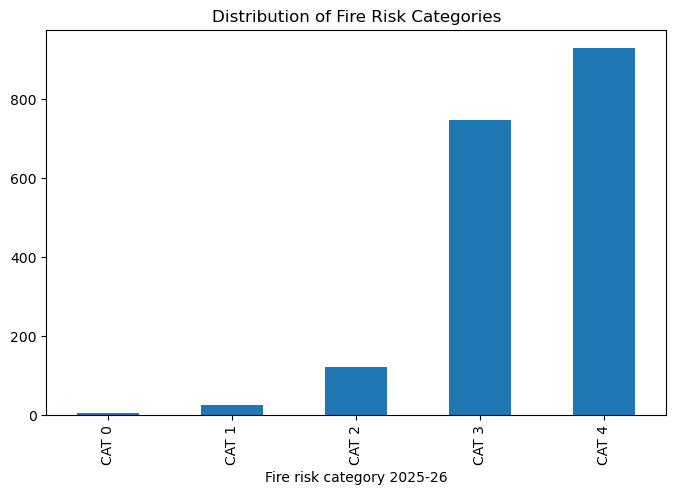

In [23]:
risk_counts = (
    df["Fire risk category 2025-26"]
    .value_counts()
    .sort_index()
)

print(risk_counts)

risk_counts.plot(
    kind="bar",
    figsize=(8,5),
    title="Distribution of Fire Risk Categories"
)

## 7. Education Sector Analysis

This section analyses the distribution of facilities across different education sectors.

Understanding this distribution helps identify which sectors contain the largest number of facilities in bushfire-prone areas.

Education sector
Early Childhood Services    975
Government                  617
Independent                 141
Catholic                     91
ELV                           2
Name: count, dtype: int64


<Axes: title={'center': 'Education Sector Distribution'}, xlabel='Education sector'>

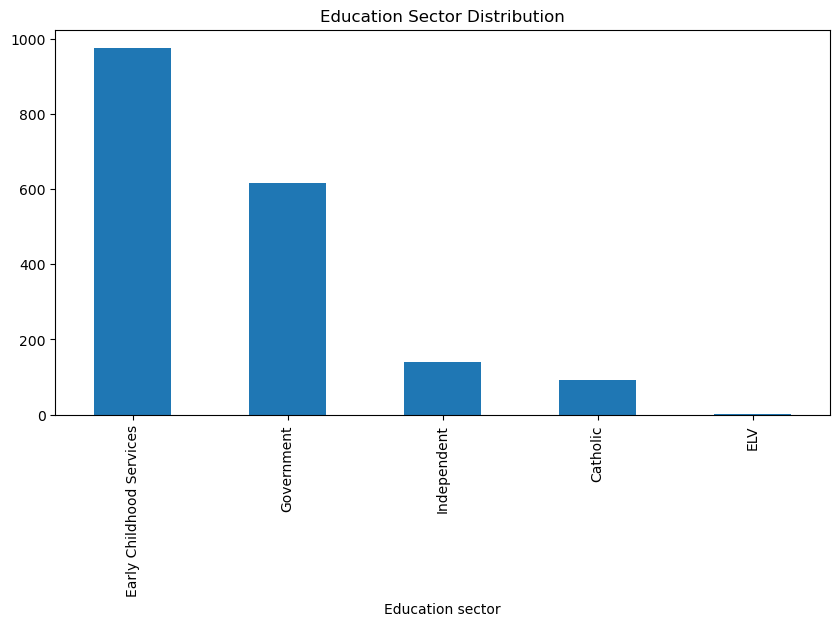

In [24]:
education_counts = (
    df["Education sector"]
    .value_counts()
)

print(education_counts)

education_counts.plot(
    kind="bar",
    figsize=(10,5),
    title="Education Sector Distribution"
)

## 8. Local Government Area (LGA) Analysis

Facilities are grouped by Local Government Area (LGA) to identify which regions contain the highest number of bushfire-at-risk educational facilities.

LGA
Yarra Ranges            173
Greater Bendigo          84
Mornington Peninsula     81
Nillumbik                73
Cardinia                 66
Casey                    64
Macedon Ranges           53
Baw Baw                  53
Greater Geelong          51
East Gippsland           48
Frankston                48
Latrobe                  45
Ballarat                 43
Greater Shepparton       39
Wellington               38
Golden Plains            32
Wangaratta               31
Manningham               30
Mount Alexander          29
South Gippsland          29
Name: count, dtype: int64


<Axes: title={'center': 'Top 20 LGAs by Number of Facilities'}, xlabel='LGA'>

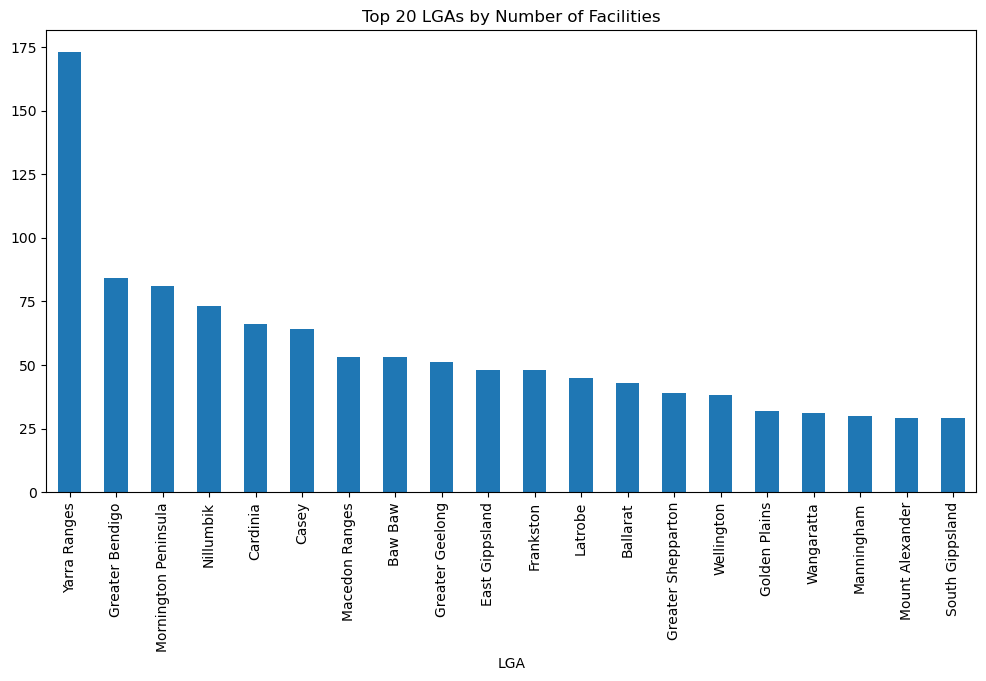

In [25]:
lga_counts = (
    df["LGA"]
    .value_counts()
)

print(lga_counts.head(20))

lga_counts.head(20).plot(
    kind="bar",
    figsize=(12,6),
    title="Top 20 LGAs by Number of Facilities"
)

## 9. Fire Weather District Analysis

Fire Weather Districts are operational regions used for bushfire forecasting and emergency management.

This analysis shows how facilities are distributed across these districts.

Fire weather district
Central                     961
Northern Country            186
West and South Gippsland    165
South West                  152
North East                  121
North Central                91
Wimmera                      57
East Gippsland               50
Mallee                       43
Name: count, dtype: int64


<Axes: title={'center': 'Fire Weather District Distribution'}, xlabel='Fire weather district'>

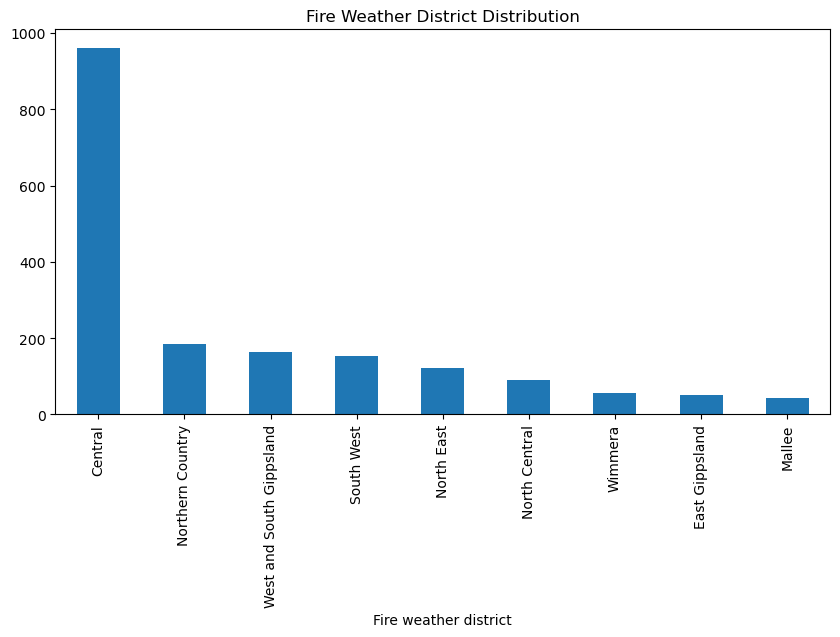

In [26]:
district_counts = (
    df["Fire weather district"]
    .value_counts()
)

print(district_counts)

district_counts.plot(
    kind="bar",
    figsize=(10,5),
    title="Fire Weather District Distribution"
)

## 10. Data Quality and Formatting Checks

Although the dataset contains no missing or duplicate records, it is important to check for formatting inconsistencies that could affect database integration or data matching.

The following checks are performed:

- Leading or trailing whitespace
- Inconsistent capitalisation
- Duplicate facility names
- Duplicate facility addresses
- Facilities sharing the same address

In [28]:
# Check for leading or trailing whitespace

for column in [
    "Facility name",
    "Facility address",
    "Town/Suburb",
    "LGA",
    "Fire weather district",
]:
    whitespace = (
        df[column]
        != df[column].astype(str).str.strip()
    ).sum()

    print(f"{column}: {whitespace}")

Facility name: 0
Facility address: 0
Town/Suburb: 0
LGA: 0
Fire weather district: 0


## 11. Duplicate Facility Names

Some organisations may operate multiple campuses using the same facility name.

This analysis identifies repeated facility names for further inspection.

In [29]:
duplicate_names = df[
    df.duplicated(
        subset=["Facility name"],
        keep=False
    )
].sort_values("Facility name")

print(f"Duplicate facility name records: {len(duplicate_names)}")

duplicate_names

Duplicate facility name records: 44


,_id,Fire risk category 2025-26,Facility name,Education sector,Facility address,Town/Suburb,LGA,Fire weather district
1034,1035,CAT 4,Butterflies Childcare & Early Learning Centre,Early Childhood Services,20 Mulwala Dr,Doreen,Whittlesea,Central
1033,1034,CAT 4,Butterflies Childcare & Early Learning Centre,Early Childhood Services,2-4 Orchard Rd,Doreen,Whittlesea,Central
515,516,CAT 3,Mount Evelyn Primary School Combined OSHC,Early Childhood Services,33 Monbulk Rd,Mount Evelyn,Yarra Ranges,Central
516,517,CAT 3,Mount Evelyn Primary School Combined OSHC,Early Childhood Services,1360 Healesville-Koo Wee Rup Rd,Woori Yallock,Yarra Ranges,Central
621,622,CAT 3,Sacred Heart School,Catholic,25 Gipson St,Diamond Creek,Nillumbik,Central
1598,1599,CAT 4,Sacred Heart School,Catholic,39 Robertson St,Casterton,Glenelg,South West
1628,1629,CAT 4,Sports DS Pty Ltd,Early Childhood Services,2 Parker St,Officer,Cardinia,Central
1627,1628,CAT 4,Sports DS Pty Ltd,Early Childhood Services,84 Railway Av,Garfield,Cardinia,Central
1636,1637,CAT 4,St Augustine's School,Catholic,119 Napier St,Creswick,Hepburn,Central
1637,1638,CAT 4,St Augustine's School,Catholic,80 Golf Links Rd,Frankston South,Frankston,Central


## 12. Duplicate Facility Addresses

Different facilities may legitimately operate from the same address.

This analysis identifies repeated addresses so they can be reviewed before database integration.

In [30]:
duplicate_addresses = df[
    df.duplicated(
        subset=["Facility address"],
        keep=False
    )
].sort_values("Facility address")

print(f"Duplicate address records: {len(duplicate_addresses)}")

duplicate_addresses

Duplicate address records: 689


,_id,Fire risk category 2025-26,Facility name,Education sector,Facility address,Town/Suburb,LGA,Fire weather district
242,243,CAT 3,Elysium OSHC - Balnarring,Early Childhood Services,1 Civic Ct,Balnarring,Mornington Peninsula,Central
42,43,CAT 3,Balnarring Primary School,Government,1 Civic Ct,Balnarring,Mornington Peninsula,Central
1238,1239,CAT 4,Gordon Primary School,Government,1 Dicker St,Gordon,Moorabool,Central
1237,1238,CAT 4,Gordon OHSC,Early Childhood Services,1 Dicker St,Gordon,Moorabool,Central
680,681,CAT 3,"St Brigid's Outside School Hours Care, Healesv...",Early Childhood Services,1 High St,Healesville,Yarra Ranges,Central
...,...,...,...,...,...,...,...,...
58,59,CAT 3,Beechworth Kindergarten Inc.,Early Childhood Services,"May Day Hills, Albert Rd",Beechworth,Indigo,North East
543,544,CAT 3,Nicholson Primary School,Government,Princes Hwy,Nicholson,East Gippsland,East Gippsland
1482,1483,CAT 4,Narrawong District Primary School,Government,Princes Hwy,Narrawong,Glenelg,South West
243,244,CAT 3,Elysium OSHC - Wallaroo,Early Childhood Services,Stalwart Av,Hastings,Mornington Peninsula,Central


## 13. Unique Values

The number of unique values is calculated for important categorical fields to better understand the diversity of the dataset.

In [31]:
columns = [
    "Town/Suburb",
    "LGA",
    "Fire weather district",
    "Education sector",
    "Fire risk category 2025-26"
]

for column in columns:
    print(f"{column}: {df[column].nunique()} unique values")

Town/Suburb: 698 unique values
LGA: 74 unique values
Fire weather district: 9 unique values
Education sector: 5 unique values
Fire risk category 2025-26: 5 unique values


## 14. Key Findings

The exploratory data analysis indicates that the dataset is structurally complete and suitable for further analysis and database integration.

The following observations were made:

- The dataset contains no missing values, duplicate rows or duplicate identifiers.
- Duplicate facility names exist but correspond to different physical locations and are therefore valid.
- Multiple facilities share the same address, which is expected where schools and Early Childhood Services operate on the same campus.
- The majority of facilities fall within the higher bushfire risk categories (CAT 3 and CAT 4).
- The Central Fire Weather District contains the highest number of registered facilities.
- Yarra Ranges is the Local Government Area with the greatest concentration of facilities.

# 15. Conclusion

The Bushfire At Risk Register dataset contains 1,826 facility records across eight attributes.

Initial data quality assessment confirmed that the dataset contains no missing values, duplicate records or missing identifiers, indicating that it is well maintained.

Exploratory analysis showed that CAT 3 and CAT 4 facilities account for the majority of records, highlighting that most registered facilities are located within higher bushfire risk areas.

The largest number of facilities belong to the Early Childhood Services and Government education sectors, while Yarra Ranges contains the highest concentration of registered facilities.

Logical duplication identified during analysis represents legitimate real-world relationships rather than data quality issues. Multiple education services may operate from the same address, and school names such as *St Mary's School* and *St Joseph's School* occur in different towns across Victoria.

Overall, the dataset is suitable for database integration, spatial analysis and further bushfire risk modelling with minimal preprocessing.